In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from tqdm import tqdm



# *Dataset Loading and Preprocessing*

# Images are loaded class-wise, resized to a fixed resolution, and flattened into
# feature vectors. This controlled representation enables classical machine
# learning models to operate on image data while keeping dimensionality manageable.


In [2]:
DATASET_ROOT = "/kaggle/input/plantvillage-dataset"
DATA_VARIANT = "color"          # primary experiment uses color images

TARGET_SIZE = (64, 64)          # controlled dimensionality
TEST_SPLIT = 0.20
RANDOM_STATE = 42


In [3]:
dataset_path = Path(DATASET_ROOT) / DATA_VARIANT
assert dataset_path.exists(), "Dataset path does not exist"

class_dirs = [d for d in dataset_path.iterdir() if d.is_dir()]
print(f"Number of classes detected: {len(class_dirs)}")

print("Sample class names:")
for d in class_dirs[:5]:
    print(" -", d.name)


Number of classes detected: 38
Sample class names:
 - Tomato___Late_blight
 - Tomato___healthy
 - Grape___healthy
 - Orange___Haunglongbing_(Citrus_greening)
 - Soybean___healthy


In [4]:
def load_flattened_dataset(root_dir, target_size):
    X = []
    y = []

    class_dirs = sorted([d for d in root_dir.iterdir() if d.is_dir()])

    for class_dir in tqdm(class_dirs, desc="Loading classes"):
        label = class_dir.name
        images = list(class_dir.iterdir())

        for img_path in tqdm(images, desc=f"{label}", leave=False):
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize(target_size)

                img_array = np.asarray(img)
                flat_vector = img_array.flatten()

                X.append(flat_vector)
                y.append(label)

            except Exception:
                continue

    return np.array(X), np.array(y)


In [5]:
X, y = load_flattened_dataset(dataset_path, TARGET_SIZE)

print("Total samples:", X.shape[0])
print("Feature dimension:", X.shape[1])
print("Number of classes:", len(np.unique(y)))


Loading classes:  18%|█▊        | 7/38 [00:39<03:09,  6.12s/it]                      
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:   0%|          | 0/513 [00:00<?, ?it/s]
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:   4%|▍         | 20/513 [00:00<00:02, 198.68it/s]
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:   8%|▊         | 41/513 [00:00<00:02, 201.43it/s]
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:  12%|█▏        | 63/513 [00:00<00:02, 207.85it/s]
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:  16%|█▋        | 84/513 [00:00<00:02, 204.65it/s]
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:  20%|██        | 105/513 [00:00<00:01, 205.38it/s]
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:  25%|██▍       | 126/513 [00:00<00:01, 202.41it/s]
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:  29%|██▊       | 147/513 [00:00<00:01, 202.43it/s]
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:  33%|███▎      | 168/513 [00:00<00:01, 203.85it/s]
Co

Total samples: 54305
Feature dimension: 12288
Number of classes: 38


# *Train–Test Split and Feature Scaling*

# The dataset is split into stratified training and test sets. Features are
# standardized to zero mean and unit variance, which is essential for
# distance-based and margin-based models such as SVMs.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SPLIT,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Train samples: 43444
Test samples: 10861


In [7]:
scaler = StandardScaler()

print("Scaling training data...")
X_train_scaled = scaler.fit_transform(X_train)

print("Scaling test data...")
X_test_scaled = scaler.transform(X_test)



Scaling training data...
Scaling test data...



# A most-frequent-class classifier is used as a sanity-check baseline. Any
# meaningful model must outperform this reference to be considered valid.

In [8]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_scaled, y_train)

dummy_preds = dummy.predict(X_test_scaled)
dummy_acc = accuracy_score(y_test, dummy_preds)

print(f"Dummy Baseline Accuracy: {dummy_acc:.4f}")


Dummy Baseline Accuracy: 0.1015


print("Training Linear SVM...")

linear_svm = LinearSVC(
    C=1.0,
    max_iter=2000,        
    dual=False,           
    random_state=RANDOM_STATE
)
linear_svm.fit(X_train_scaled, y_train)

print("Predicting with Linear SVM...")
linear_preds = linear_svm.predict(X_test_scaled)

linear_acc = accuracy_score(y_test, linear_preds)
print(f"Linear SVM Accuracy: {linear_acc:.4f}")


# Direct Linear SVM training on 12k-dimensional raw pixel vectors with
# ~43k samples proved computationally prohibitive in an interactive environment.
# Therefore, PCA was applied to reduce dimensionality before training.
# This preserves most variance while enabling feasible optimization.

# Principal Component Analysis (PCA) is applied to compress high-dimensional pixel
# features into a lower-dimensional representation while retaining most of the
# variance. This step enables feasible training of classical models at scale.

# PCA + Linear SVM 

# A Linear SVM is trained on PCA-reduced features to establish a strong and scalable
# classical baseline. This model represents the practical performance ceiling of
# linear methods on raw pixel representations.


In [22]:
print("Running PCA dimensionality reduction...")

pca = PCA(
    n_components=256,
    svd_solver="randomized",
    random_state=RANDOM_STATE
)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(
    "Explained variance by PCA:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

print("Training Linear SVM on PCA features...")

pca_svm = LinearSVC(
    C=2.0,
    max_iter=3000,
    dual=False,
    random_state=RANDOM_STATE
)

pca_svm.fit(X_train_pca, y_train)

print("Predicting with PCA + Linear SVM...")
pca_preds = pca_svm.predict(X_test_pca)

pca_acc = accuracy_score(y_test, pca_preds)
print(f"PCA + Linear SVM Accuracy: {pca_acc:.4f}")

print("\nClassification Report — PCA + Linear SVM")
print(classification_report(y_test, pca_preds))



Running PCA dimensionality reduction...
Explained variance by PCA: 0.9037
Training Linear SVM on PCA features...
Predicting with PCA + Linear SVM...
PCA + Linear SVM Accuracy: 0.6812

Classification Report — PCA + Linear SVM
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.63      0.60      0.62       126
                                 Apple___Black_rot       0.67      0.65      0.66       124
                          Apple___Cedar_apple_rust       0.21      0.09      0.13        55
                                   Apple___healthy       0.57      0.58      0.58       329
                               Blueberry___healthy       0.66      0.66      0.66       300
          Cherry_(including_sour)___Powdery_mildew       0.51      0.54      0.53       210
                 Cherry_(including_sour)___healthy       0.77      0.67      0.72       171
Corn_(maize)___Cercospora_leaf_spot Gr

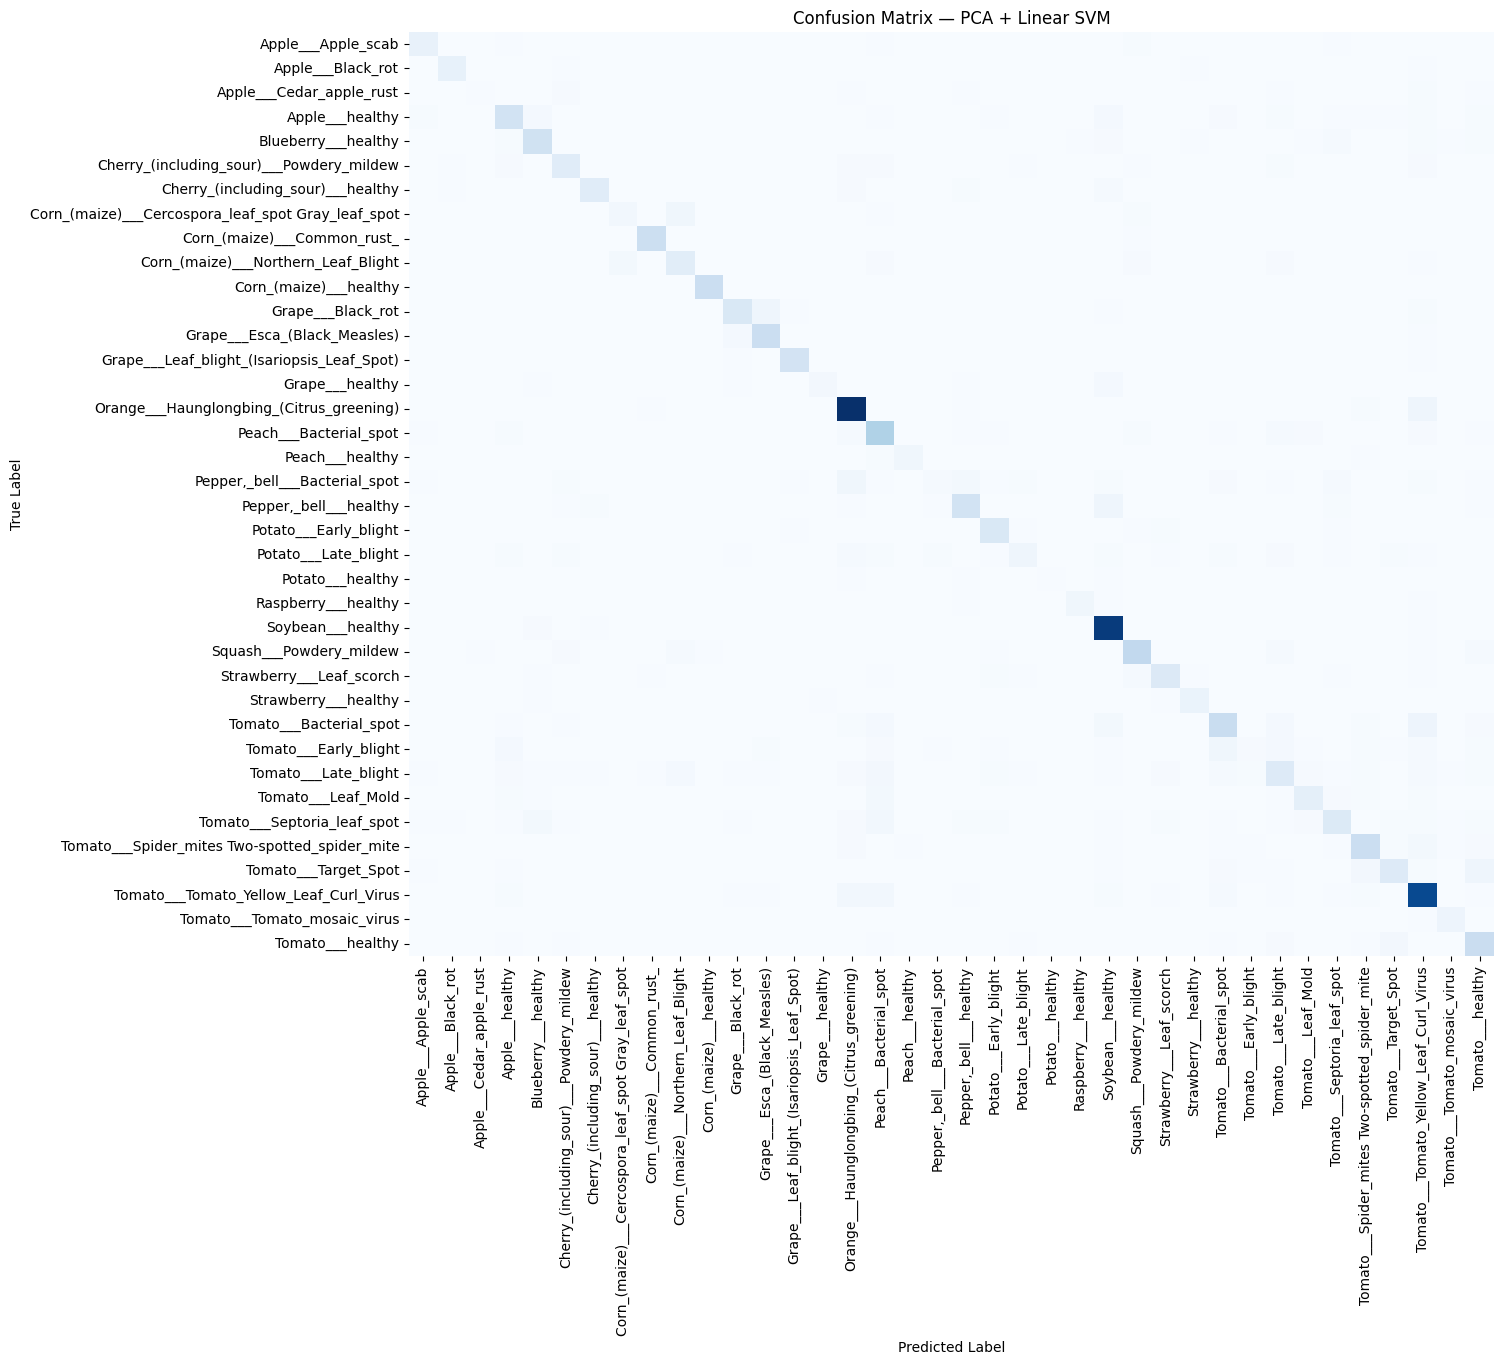

In [23]:
cm_pca = confusion_matrix(y_test, pca_preds, labels=pca_svm.classes_)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_pca,
    cmap="Blues",
    xticklabels=pca_svm.classes_,
    yticklabels=pca_svm.classes_,
    cbar=False
)
plt.title("Confusion Matrix — PCA + Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


# Random Forest (Fine-Tuned Classical Baseline)

# A depth-controlled and class-balanced Random Forest is trained on standardized
# pixel features to explore the upper performance limit of tree-based classical
# models. Moderate tuning improves generalization and class recall, but the model
# still lacks spatial awareness, highlighting the need for convolutional methods.


In [24]:
print("Subsampling training data for Random Forest...")

MAX_RF_SAMPLES = 20000
np.random.seed(RANDOM_STATE)

rf_idx = np.random.choice(
    X_train.shape[0],
    MAX_RF_SAMPLES,
    replace=False
)

X_train_rf = X_train[rf_idx]
y_train_rf = y_train[rf_idx]

print(f"Random Forest training samples: {X_train_rf.shape[0]}")



Subsampling training data for Random Forest...
Random Forest training samples: 20000


In [25]:
print("Training Random Forest (basic, tuned)...")

rf = RandomForestClassifier(
    n_estimators=400,                 # slightly more trees
    max_depth=25,                     # CRITICAL
    min_samples_leaf=2,               # reduces noise overfitting
    max_features="sqrt",              # standard RF best practice
    class_weight="balanced_subsample",# handles class imbalance
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# IMPORTANT: use SCALED data consistently
X_train_rf = X_train_scaled[rf_idx]
X_test_rf = X_test_scaled

rf.fit(X_train_rf, y_train_rf)

print("Predicting with Random Forest...")
rf_preds = rf.predict(X_test_rf)

rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

print("\nClassification Report — Random Forest")
print(classification_report(y_test, rf_preds))



Training Random Forest (basic, tuned)...
Predicting with Random Forest...
Random Forest Accuracy: 0.6993

Classification Report — Random Forest
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.70      0.40      0.51       126
                                 Apple___Black_rot       0.74      0.70      0.72       124
                          Apple___Cedar_apple_rust       1.00      0.02      0.04        55
                                   Apple___healthy       0.70      0.59      0.64       329
                               Blueberry___healthy       0.74      0.80      0.77       300
          Cherry_(including_sour)___Powdery_mildew       0.66      0.56      0.60       210
                 Cherry_(including_sour)___healthy       0.80      0.63      0.71       171
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.53      0.17      0.26       103
                       Corn

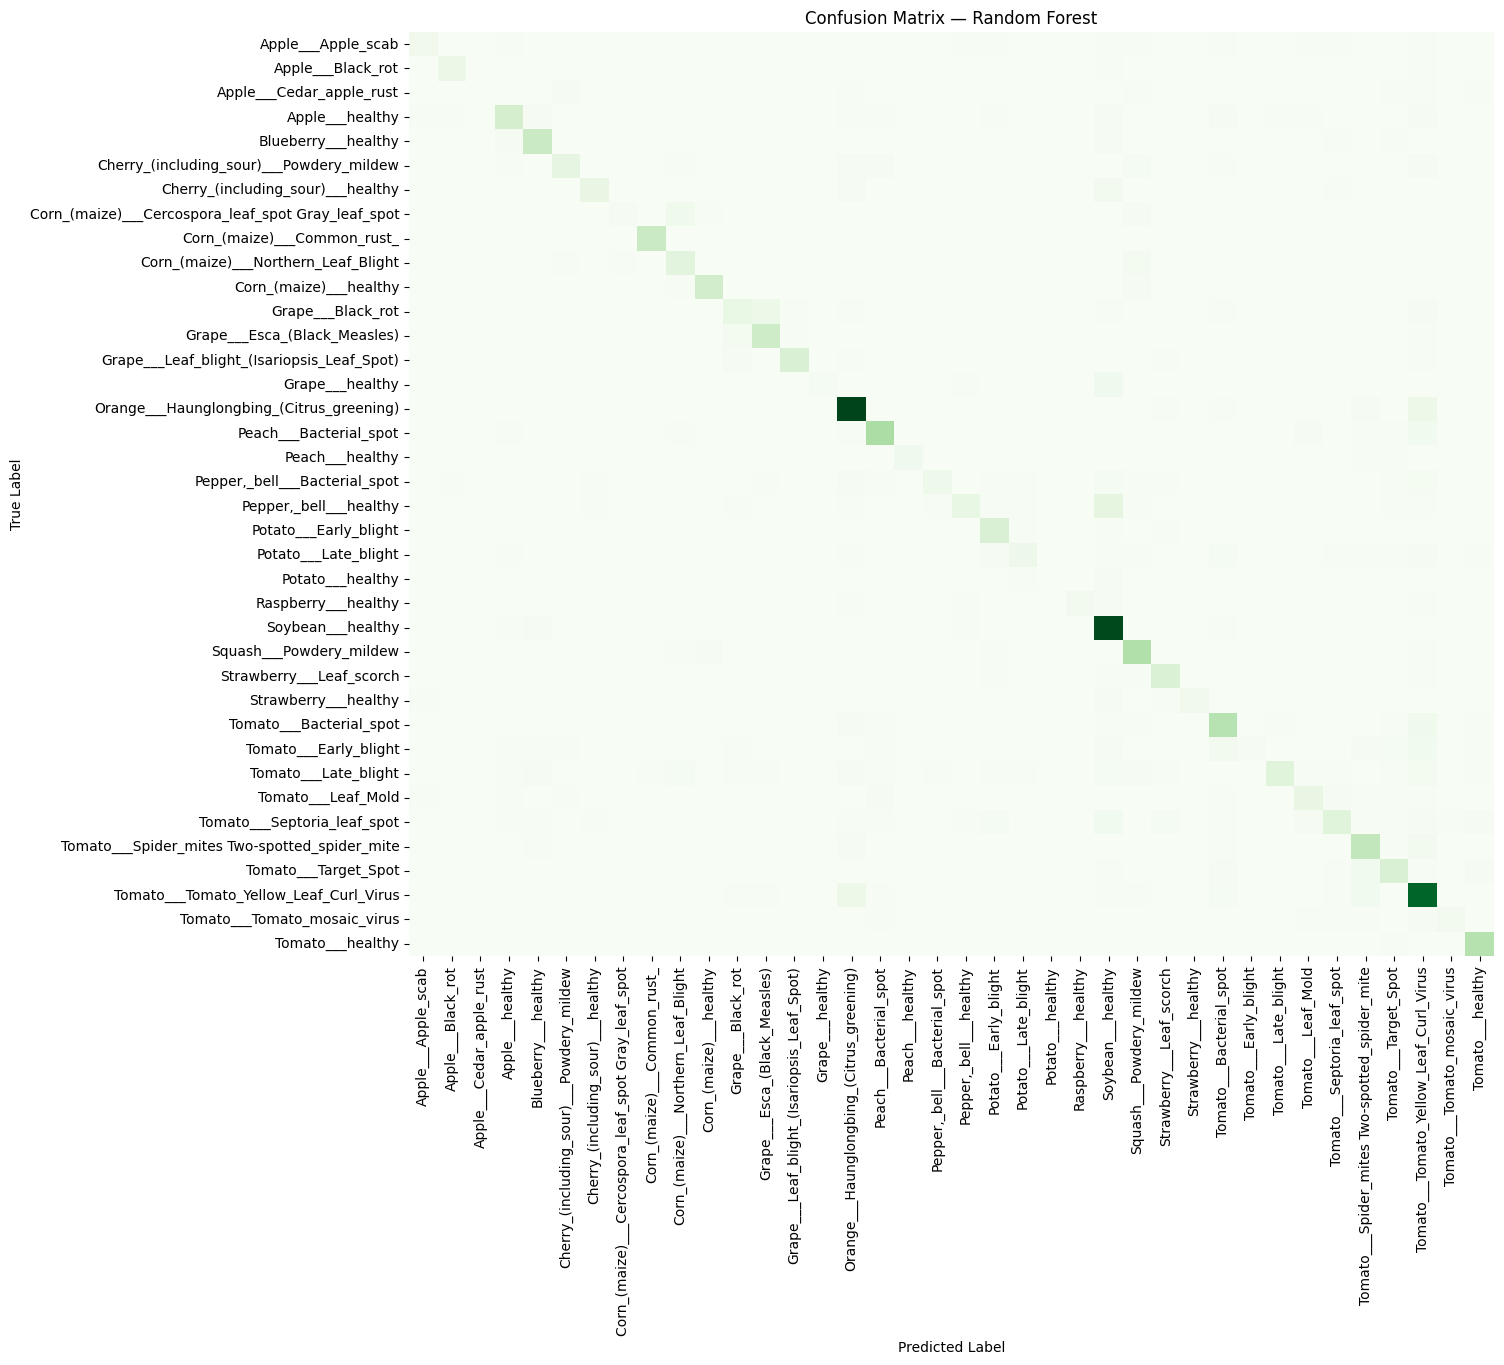

In [26]:
cm_rf = confusion_matrix(y_test, rf_preds, labels=rf.classes_)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_rf,
    cmap="Greens",
    xticklabels=rf.classes_,
    yticklabels=rf.classes_,
    cbar=False
)
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


# Random Forest on PCA Features

# A Random Forest classifier is trained on PCA-compressed features to evaluate the
# capabilities of non-linear, tree-based models. Training is performed on a
# randomized subsample to balance computational cost and model expressiveness.

In [27]:
print("Training Random Forest on PCA features...")

MAX_RF_SAMPLES = 25000
np.random.seed(RANDOM_STATE)

rf_idx = np.random.choice(
    X_train_pca.shape[0],
    MAX_RF_SAMPLES,
    replace=False
)

X_train_rf = X_train_pca[rf_idx]
y_train_rf = y_train[rf_idx]

X_test_rf = X_test_pca

rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=25,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train_rf, y_train_rf)

rf_preds = rf.predict(X_test_rf)

rf_pca_acc = accuracy_score(y_test, rf_preds)
print(f"Random Forest (PCA) Accuracy: {rf_acc:.4f}")

print("\nClassification Report — Random Forest (PCA)")
print(classification_report(y_test, rf_preds))


Training Random Forest on PCA features...
Random Forest (PCA) Accuracy: 0.6993

Classification Report — Random Forest (PCA)
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.83      0.32      0.46       126
                                 Apple___Black_rot       0.82      0.60      0.69       124
                          Apple___Cedar_apple_rust       0.00      0.00      0.00        55
                                   Apple___healthy       0.56      0.62      0.59       329
                               Blueberry___healthy       0.72      0.67      0.70       300
          Cherry_(including_sour)___Powdery_mildew       0.85      0.49      0.62       210
                 Cherry_(including_sour)___healthy       0.88      0.49      0.63       171
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.71      0.15      0.24       103
                       Corn_(maize)___Common_ru

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


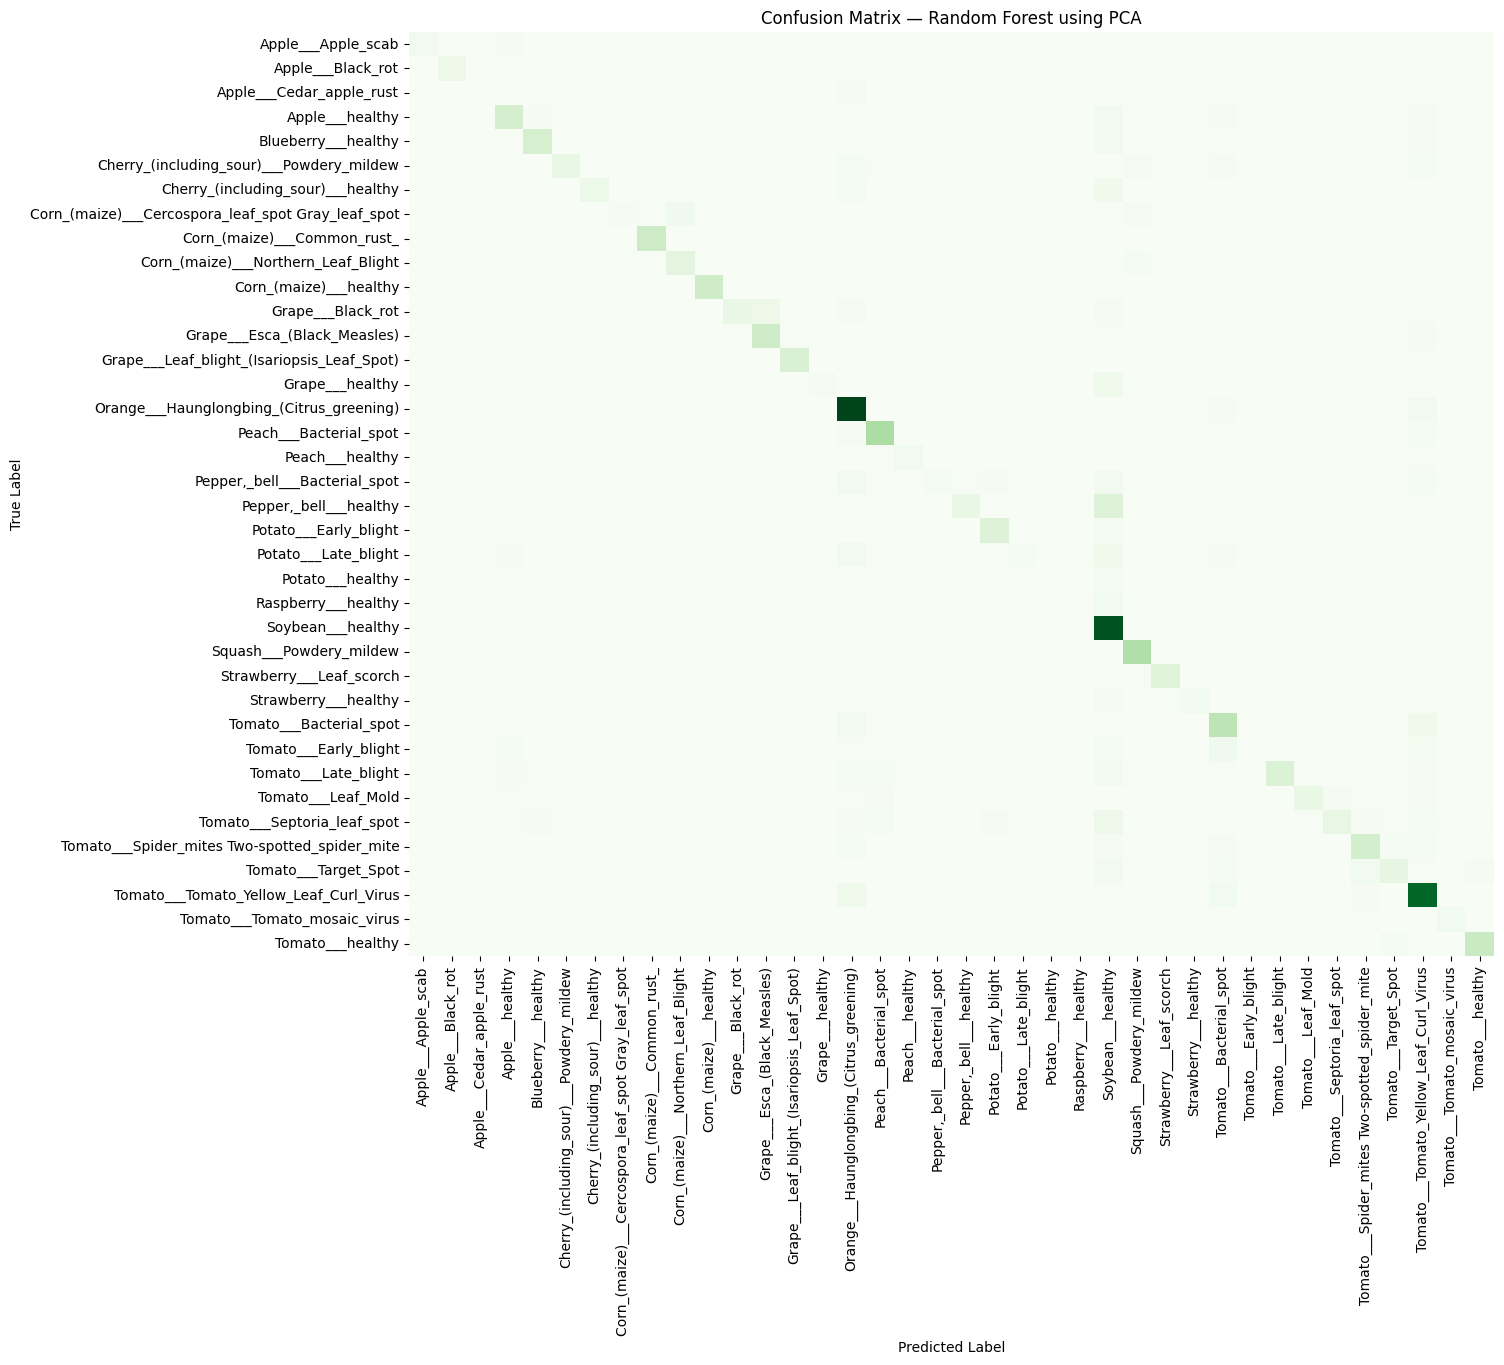

In [30]:
cm_rf = confusion_matrix(y_test, rf_preds, labels=rf.classes_)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_rf,
    cmap="Greens",
    xticklabels=rf.classes_,
    yticklabels=rf.classes_,
    cbar=False
)
plt.title("Confusion Matrix — Random Forest using PCA")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# RBF SVM 

# Kernel SVMs scale quadratically with the number of samples and are computationally
# infeasible at full scale. A stratified subsample is therefore used to demonstrate
# the limitations of kernel methods on high-dimensional image data.


In [31]:
print("Preparing stratified subsample for RBF SVM...")

MAX_SAMPLES = 12000
np.random.seed(RANDOM_STATE)

# Stratified subsampling
df_train = pd.DataFrame({"label": y_train})
df_train["idx"] = np.arange(len(y_train))

rbf_sampled = (
    df_train
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(
        n=max(1, int(MAX_SAMPLES * len(x) / len(df_train))),
        random_state=RANDOM_STATE
    ))
)

rbf_idx = rbf_sampled["idx"].values

X_train_rbf = X_train_scaled[rbf_idx]
y_train_rbf = y_train[rbf_idx]

print(f"RBF SVM training samples: {len(y_train_rbf)}")


Preparing stratified subsample for RBF SVM...


/tmp/ipykernel_55/2020710049.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


RBF SVM training samples: 11980


In [32]:
print("Training RBF SVM")

rbf_svm = SVC(
    kernel="rbf",
    C=2.0,
    gamma="scale"
)

rbf_svm.fit(X_train_rbf, y_train_rbf)


Training RBF SVM


SVC(C=2.0)

In [33]:
print("Preparing test subsample for RBF SVM evaluation...")

MAX_TEST_SAMPLES = 4000

test_idx = np.random.choice(
    X_test_scaled.shape[0],
    MAX_TEST_SAMPLES,
    replace=False
)

X_test_rbf = X_test_scaled[test_idx]
y_test_rbf = y_test[test_idx]


Preparing test subsample for RBF SVM evaluation...


In [34]:
print("Predicting with RBF SVM...")

rbf_preds = rbf_svm.predict(X_test_rbf)

rbf_acc = accuracy_score(y_test_rbf, rbf_preds)
print(f"RBF SVM (subsampled) Accuracy: {rbf_acc:.4f}")

print("\nClassification Report — RBF SVM")
print(classification_rep
      
      
      ort(y_test_rbf, rbf_preds))


Predicting with RBF SVM...
RBF SVM (subsampled) Accuracy: 0.7735

Classification Report — RBF SVM
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.62      0.37      0.46        41
                                 Apple___Black_rot       0.83      0.81      0.82        48
                          Apple___Cedar_apple_rust       1.00      0.17      0.29        24
                                   Apple___healthy       0.64      0.72      0.68       124
                               Blueberry___healthy       0.72      0.88      0.79       118
          Cherry_(including_sour)___Powdery_mildew       0.67      0.79      0.72        71
                 Cherry_(including_sour)___healthy       0.81      0.75      0.78        68
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.62      0.24      0.35        41
                       Corn_(maize)___Common_rust_       0.96      1.00  

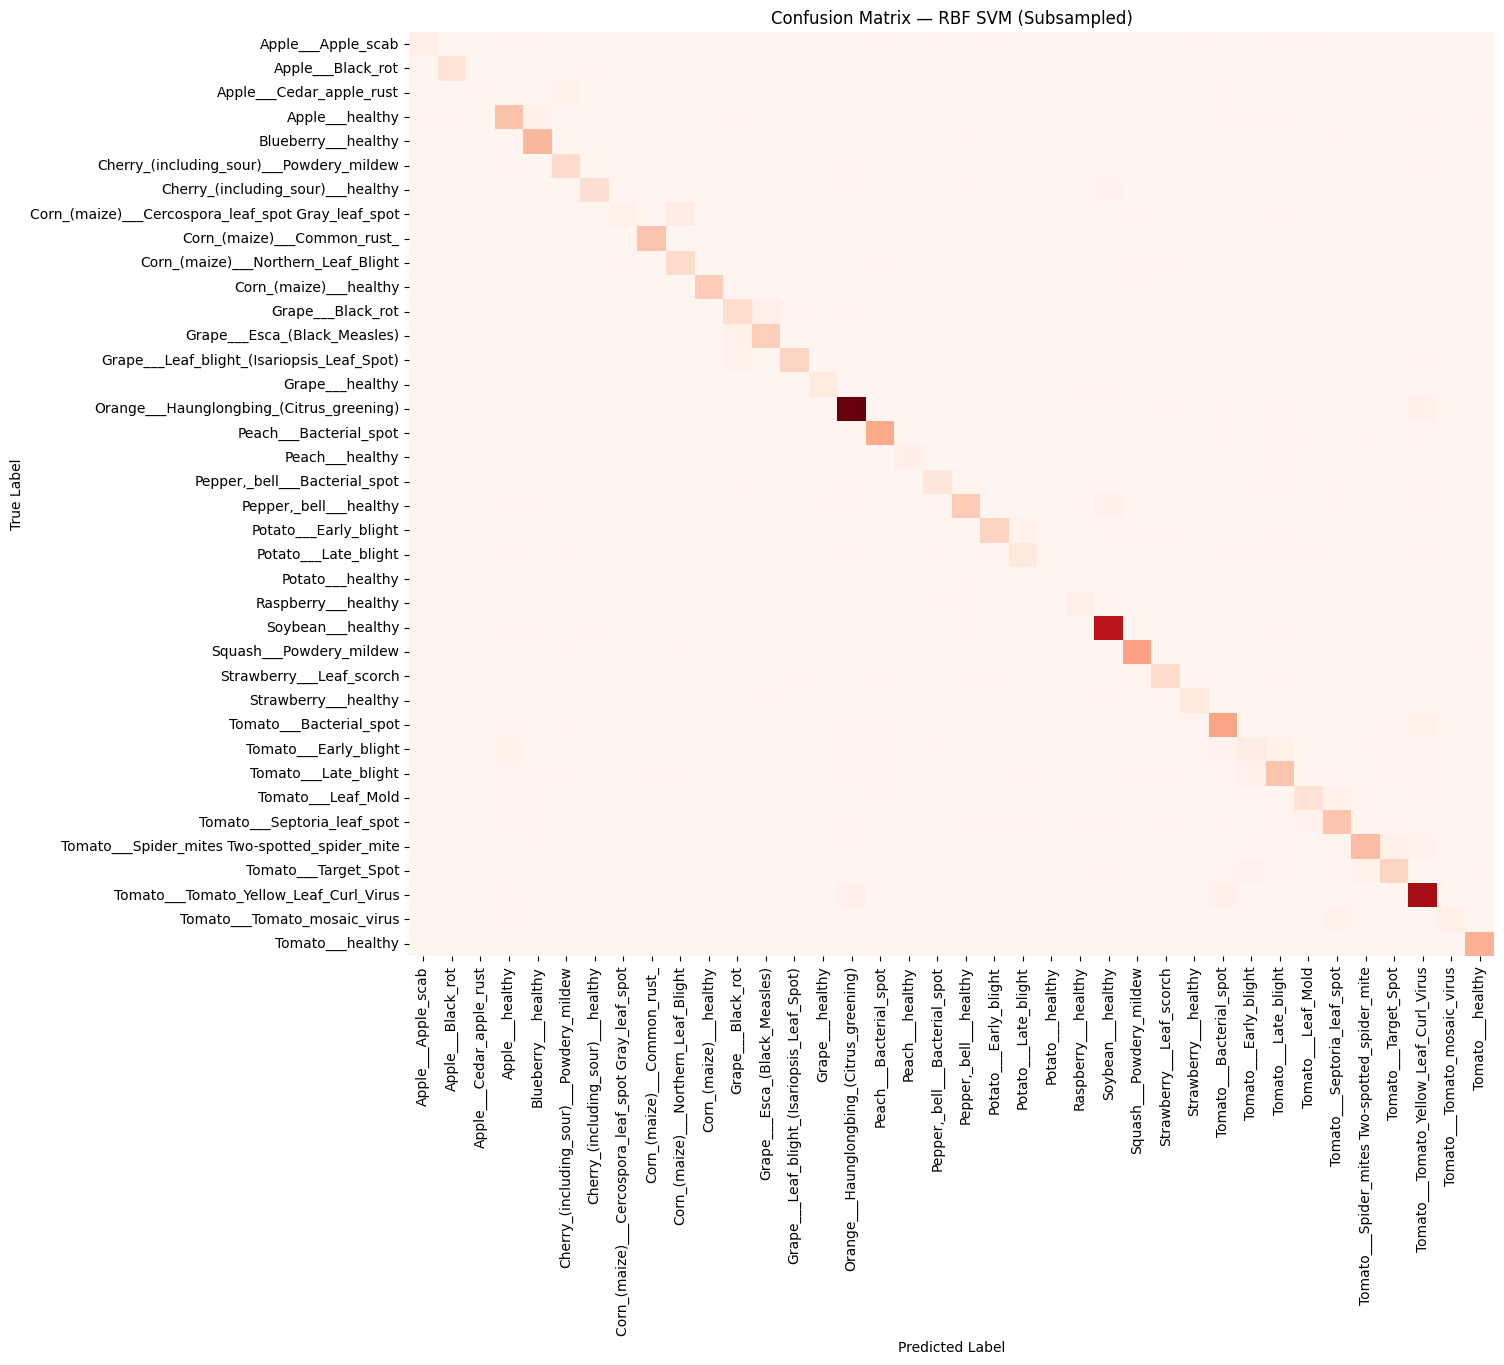

In [35]:
cm_rbf = confusion_matrix(y_test_rbf, rbf_preds, labels=rbf_svm.classes_)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_rbf,
    cmap="Reds",
    xticklabels=rbf_svm.classes_,
    yticklabels=rbf_svm.classes_,
    cbar=False
)
plt.title("Confusion Matrix — RBF SVM (Subsampled)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


In [36]:
results = pd.DataFrame({
    "Model": [
        "Dummy",
        "PCA + Linear SVM",
        "Random Forest",
        "Random Forest + PCA",
        "RBF SVM (subsampled)"
    ],
    "Accuracy": [
        dummy_acc,
        pca_acc,
        rf_acc,
        rf_pca_acc,
        rbf_acc
    ]
})

results


,Model,Accuracy
0,Dummy,0.101464
1,PCA + Linear SVM,0.681153
2,Random Forest,0.699291
3,Random Forest + PCA,0.675997
4,RBF SVM (subsampled),0.773500
